In [ ]:
import zipfile

with zipfile.ZipFile("Crime_Data_from_2020_to_Present.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
# CELL 1: Install Required Libraries
!pip install -q torch-geometric xgboost tabulate shap networkx

import os
import warnings
warnings.filterwarnings('ignore') # Suppress Pandas date parsing warnings

# Create the necessary directory structure in Colab's virtual environment
os.makedirs('/content/data/raw', exist_ok=True)
os.makedirs('/content/reports/figures', exist_ok=True)

print("✅ Environment setup complete. Directories created.")
print("⚠️ ACTION REQUIRED: Open the folder icon on the left, navigate to /content/data/raw/, and upload your 'crime_data.csv' file there before continuing.")

✅ Environment setup complete. Directories created.
⚠️ ACTION REQUIRED: Open the folder icon on the left, navigate to /content/data/raw/, and upload your 'crime_data.csv' file there before continuing.


In [ ]:
# CELL 2: Configuration
import torch
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from torch.optim import AdamW
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

class Config:
    SEED = 42
    CELL_SIZE = 0.01
    WINDOW_SIZE = 6
    SIMILARITY_THRESHOLD = 0.8

    # Model
    GAT_HEADS_1 = 4
    GAT_HIDDEN_1 = 128
    GAT_HEADS_2 = 1
    GAT_HIDDEN_2 = 64
    TRANSFORMER_LAYERS = 2
    TRANSFORMER_HEADS = 4
    D_MODEL = 64
    DIM_FEEDFORWARD = 128

    # Training
    LEARNING_RATE = 0.0005
    WEIGHT_DECAY = 1e-4
    EPOCHS = 100
    PATIENCE = 10

    # Paths
    RAW_DATA_PATH = "/content/data/raw/crime_data.csv"
    PROCESSED_DIR = "/content/reports/"
    FIGURES_DIR = "/content/reports/figures/"
    MODEL_SAVE_PATH = "/content/reports/best_model.pt"

def set_seed(seed=Config.SEED):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Configured. Using Device: {device}")

✅ Configured. Using Device: cuda


In [ ]:
# CELL 3: Data Pipeline
def load_and_simulate_data(filepath):
    print("Loading crime data...")
    df = pd.read_csv(filepath)
    df = df[(df['LAT'] != 0) & (df['LON'] != 0)].copy()

    # Using format='mixed' handles the LAPD date format gracefully
    df['DATE OCC'] = pd.to_datetime(df['DATE OCC'], format='mixed', errors='coerce')
    df['Month_Period'] = df['DATE OCC'].dt.to_period('M')

    print("Simulating surveillance data...")
    surveillance_records = []
    for _, row in df.iterrows():
        if np.random.rand() > 0.1: # 10% noise
            desc = str(row['Crm Cd Desc']).lower()
            event_type = 'general_alert'
            if not pd.isna(row['Weapon Used Cd']) or 'weapon' in desc or 'firearm' in desc: event_type = 'weapon'
            elif 'assault' in desc or 'battery' in desc: event_type = 'fight'
            elif 'shoplifting' in desc or 'theft' in desc: event_type = 'shoplifting'

            surveillance_records.append({
                'timestamp': row['DATE OCC'],
                'lat': row['LAT'] + np.random.normal(0, 0.001),
                'lon': row['LON'] + np.random.normal(0, 0.001),
                'event_type': event_type
            })
    surv_df = pd.DataFrame(surveillance_records)
    surv_df['Month_Period'] = surv_df['timestamp'].dt.to_period('M')
    return df, surv_df

def create_spatial_grid(df):
    df['grid_x'] = np.floor(df['LON'] / Config.CELL_SIZE).astype(int)
    df['grid_y'] = np.floor(df['LAT'] / Config.CELL_SIZE).astype(int)
    df['grid_coord'] = df['grid_x'].astype(str) + '_' + df['grid_y'].astype(str)

    unique_grids = df['grid_coord'].unique()
    grid_mapping = {coord: idx for idx, coord in enumerate(unique_grids)}
    df['grid_id'] = df['grid_coord'].map(grid_mapping)
    return df, grid_mapping

def build_features(crime_df, surv_df, grid_mapping):
    print("Aggregating monthly features...")
    # Crime feats
    crime_df['is_part1'] = crime_df['Part 1-2'].astype(str).str.contains('1', na=False).astype(int)
    crime_df['is_weapon'] = crime_df['Weapon Used Cd'].notna().astype(int)
    crime_df['is_assault'] = crime_df['Crm Cd Desc'].str.lower().str.contains('assault|battery').astype(int)

    crime_agg = crime_df.groupby(['grid_id', 'Month_Period']).agg(
        crime_count=('DATE OCC', 'count'), part1_sum=('is_part1', 'sum'),
        weapon_sum=('is_weapon', 'sum'), assault_sum=('is_assault', 'sum')
    ).reset_index()
    crime_agg['part1_ratio'] = crime_agg['part1_sum'] / crime_agg['crime_count']
    crime_agg['weapon_ratio'] = crime_agg['weapon_sum'] / crime_agg['crime_count']
    crime_agg['assault_ratio'] = crime_agg['assault_sum'] / crime_agg['crime_count']

    # Surv feats
    surv_df['grid_x'] = np.floor(surv_df['lon'] / Config.CELL_SIZE).astype(int)
    surv_df['grid_y'] = np.floor(surv_df['lat'] / Config.CELL_SIZE).astype(int)
    surv_df['grid_coord'] = surv_df['grid_x'].astype(str) + '_' + surv_df['grid_y'].astype(str)
    surv_df = surv_df[surv_df['grid_coord'].isin(grid_mapping.keys())].copy()
    surv_df['grid_id'] = surv_df['grid_coord'].map(grid_mapping)

    surv_df['is_weapon_alert'] = (surv_df['event_type'] == 'weapon').astype(int)
    surv_df['is_fight_alert'] = (surv_df['event_type'] == 'fight').astype(int)
    surv_df['is_shoplifting_alert'] = (surv_df['event_type'] == 'shoplifting').astype(int)
    surv_agg = surv_df.groupby(['grid_id', 'Month_Period']).agg(
        weapon_alert_count=('is_weapon_alert', 'sum'), fight_alert_count=('is_fight_alert', 'sum'),
        shoplifting_alert_count=('is_shoplifting_alert', 'sum'), total_alerts=('event_type', 'count')
    ).reset_index()

    # Merge
    all_grids = list(grid_mapping.values())
    all_months = pd.period_range(start=crime_df['Month_Period'].min(), end=crime_df['Month_Period'].max(), freq='M')
    idx = pd.MultiIndex.from_product([all_grids, all_months], names=['grid_id', 'Month_Period'])
    panel = pd.DataFrame(index=idx).reset_index()
    panel = pd.merge(panel, crime_agg, on=['grid_id', 'Month_Period'], how='left')
    panel = pd.merge(panel, surv_agg, on=['grid_id', 'Month_Period'], how='left').fillna(0)

    # Rolling logic
    panel = panel.sort_values(by=['grid_id', 'Month_Period'])
    panel['lag_1'] = panel.groupby('grid_id')['crime_count'].shift(1)
    panel['lag_2'] = panel.groupby('grid_id')['crime_count'].shift(2)
    panel['rolling_mean_3'] = panel.groupby('grid_id')['lag_1'].transform(lambda x: x.rolling(3, min_periods=1).mean())
    panel['rolling_std_3'] = panel.groupby('grid_id')['lag_1'].transform(lambda x: x.rolling(3, min_periods=1).std())
    panel.fillna(0, inplace=True)

    # Tensor
    feature_cols = ['crime_count', 'part1_ratio', 'weapon_ratio', 'assault_ratio', 'rolling_mean_3', 'rolling_std_3', 'lag_1', 'lag_2', 'weapon_alert_count', 'fight_alert_count', 'shoplifting_alert_count', 'total_alerts']
    panel = panel.sort_values(by=['Month_Period', 'grid_id'])
    X_tensor = panel[feature_cols].values.reshape(len(all_months), len(all_grids), len(feature_cols))

    return panel, X_tensor, all_months, feature_cols

In [ ]:
# CELL 4: Graphs & PyTorch DataLoaders
def build_spatial_adjacency(grid_mapping):
    N = len(grid_mapping)
    W = np.zeros((N, N))
    id_to_coord = {v: k for k, v in grid_mapping.items()}
    for i in range(N):
        xi, yi = map(int, id_to_coord[i].split('_'))
        for j in range(N):
            if i == j: continue
            xj, yj = map(int, id_to_coord[j].split('_'))
            if max(abs(xi - xj), abs(yi - yj)) <= 1: W[i, j] = 1.0
    return W

def build_dynamic_graphs(X_tensor, grid_mapping):
    print("Building dynamic spatio-temporal graphs...")
    T, N, F = X_tensor.shape
    W_spatial = build_spatial_adjacency(grid_mapping)
    spatial_sources, spatial_targets = np.where(W_spatial == 1)

    dynamic_edge_indices = []
    for t in range(T):
        X_t_safe = X_tensor[t] + 1e-8
        sim_matrix = cosine_similarity(X_t_safe)
        np.fill_diagonal(sim_matrix, 0)
        sim_sources, sim_targets = np.where(sim_matrix > Config.SIMILARITY_THRESHOLD)

        edges = np.vstack([np.concatenate([spatial_sources, sim_sources]),
                           np.concatenate([spatial_targets, sim_targets])])
        edges = np.unique(edges, axis=1)
        dynamic_edge_indices.append(torch.tensor(edges, dtype=torch.long))
    return dynamic_edge_indices

class CrimeWindowDataset(Dataset):
    def __init__(self, X_tensor, edge_indices):
        super().__init__()
        self.X_tensor = torch.tensor(X_tensor, dtype=torch.float32)
        self.edge_indices = edge_indices
        self.T, self.N, self.F = self.X_tensor.shape
        self.num_samples = self.T - Config.WINDOW_SIZE

    def len(self): return self.num_samples

    def get(self, idx):
        window_x = self.X_tensor[idx : idx + Config.WINDOW_SIZE]
        node_features = window_x.permute(1, 0, 2)
        y = self.X_tensor[idx + Config.WINDOW_SIZE, :, 0]
        edge_index = self.edge_indices[idx + Config.WINDOW_SIZE - 1]
        return Data(x=node_features, edge_index=edge_index, y=y)

def create_dataloaders(X_tensor, edge_indices):
    train_cutoff = 48 - Config.WINDOW_SIZE
    dataset = CrimeWindowDataset(X_tensor, edge_indices)
    train_loader = DataLoader(dataset[:train_cutoff], batch_size=1, shuffle=True)
    test_loader = DataLoader(dataset[train_cutoff:], batch_size=1, shuffle=False)
    return train_loader, test_loader

In [ ]:
# CELL 5: Architectures
class STGAT(nn.Module):
    def __init__(self, num_features, window_size):
        super(STGAT, self).__init__()
        # Spatial
        self.gat1 = GATConv(num_features * window_size, Config.GAT_HIDDEN_1, heads=Config.GAT_HEADS_1, concat=True)
        self.gat2 = GATConv(Config.GAT_HIDDEN_1 * Config.GAT_HEADS_1, Config.GAT_HIDDEN_2, heads=Config.GAT_HEADS_2, concat=False)

        # Temporal
        self.temp_proj = nn.Linear(num_features, Config.D_MODEL)
        self.pos_encoder = nn.Parameter(torch.randn(1, window_size, Config.D_MODEL))
        encoder_layer = nn.TransformerEncoderLayer(d_model=Config.D_MODEL, nhead=Config.TRANSFORMER_HEADS, dim_feedforward=Config.DIM_FEEDFORWARD, batch_first=True, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=Config.TRANSFORMER_LAYERS)

        # Output
        self.out_linear = nn.Linear(Config.D_MODEL, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        N, W, num_feats = x.shape

        # Spatial Branch
        x_spatial = x.reshape(N, W * num_feats)
        h_spatial = F.elu(self.gat1(x_spatial, edge_index))
        h_spatial = F.elu(self.gat2(h_spatial, edge_index))

        # Temporal Branch
        x_temporal = self.temp_proj(x) + self.pos_encoder
        h_temp_seq = self.transformer(x_temporal)
        h_temporal = h_temp_seq[:, -1, :]

        # Fusion
        h_combined = h_spatial + h_temporal
        return self.out_linear(h_combined).squeeze()

class LSTMBase(nn.Module):
    def __init__(self, num_features, hidden_size=64):
        super(LSTMBase, self).__init__()
        self.lstm = nn.LSTM(input_size=num_features, hidden_size=hidden_size, batch_first=True)
        self.linear = nn.Linear(hidden_size, 1)

    def forward(self, data):
        out, _ = self.lstm(data.x)
        return self.linear(out[:, -1, :]).squeeze()

In [ ]:
# CELL 6: Training & Evaluation
def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.maximum(y_true, 1.0)))) * 100

    k = int(0.2 * len(y_true))
    if k > 0:
        top_true_idx = set(np.argsort(y_true)[-k:])
        top_pred_idx = set(np.argsort(y_pred)[-k:])
        top_20_acc = (len(top_true_idx.intersection(top_pred_idx)) / k) * 100
    else: top_20_acc = 100.0

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "R2": r2, "Top20_Acc": top_20_acc}

def print_metrics(metrics_dict, title="Results"):
    print(f"\n--- {title} ---")
    for k, v in metrics_dict.items():
        if "Acc" in k or "MAPE" in k: print(f"{k:>12}: {v:.2f}%")
        else: print(f"{k:>12}: {v:.4f}")
    print("-" * (len(title) + 8))

def train_stgat(model, train_loader, test_loader):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = AdamW(model.parameters(), lr=Config.LEARNING_RATE, weight_decay=Config.WEIGHT_DECAY)

    best_val_loss, patience_counter = float('inf'), 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(Config.EPOCHS):
        model.train()
        train_loss = 0.0
        for data in train_loader:
            data = data.to(device)
            optimizer.zero_grad()
            predictions = model(data)
            loss = criterion(predictions, data.y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)
        history['train_loss'].append(train_loss)

        model.eval()
        val_loss, all_preds, all_true = 0.0, [], []
        with torch.no_grad():
            for data in test_loader:
                data = data.to(device)
                predictions = model(data)
                val_loss += criterion(predictions, data.y).item()
                all_preds.extend(predictions.cpu().numpy())
                all_true.extend(data.y.cpu().numpy())

        val_loss /= len(test_loader)
        history['val_loss'].append(val_loss)
        metrics = compute_metrics(np.array(all_true), np.array(all_preds))

        print(f"Epoch {epoch+1:03d} | Train: {train_loss:.2f} | Val: {val_loss:.2f} | Top20_Acc: {metrics['Top20_Acc']:.1f}%")

        if val_loss < best_val_loss:
            best_val_loss, patience_counter = val_loss, 0
            torch.save(model.state_dict(), Config.MODEL_SAVE_PATH)
        else:
            patience_counter += 1
            if patience_counter >= Config.PATIENCE:
                print(f"⏹️ Early stopping at epoch {epoch+1}. Restoring best weights...")
                break

    model.load_state_dict(torch.load(Config.MODEL_SAVE_PATH))

    # Final Eval
    model.eval()
    f_preds, f_true = [], []
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            f_preds.extend(model(data).cpu().numpy())
            f_true.extend(data.y.cpu().numpy())
    best_metrics = compute_metrics(np.array(f_true), np.array(f_preds))
    return model, history, best_metrics

def train_eval_ml_baselines(train_loader, test_loader):
    print("\n" + "="*40 + "\nTRAINING CLASSICAL ML BASELINES\n" + "="*40)
    X_train, y_train, X_test, y_test = [], [], [], []
    for data in train_loader:
        X_train.append(data.x.view(data.x.shape[0], -1).cpu().numpy())
        y_train.append(data.y.cpu().numpy())
    for data in test_loader:
        X_test.append(data.x.view(data.x.shape[0], -1).cpu().numpy())
        y_test.append(data.y.cpu().numpy())

    X_train, y_train = np.vstack(X_train), np.concatenate(y_train)
    X_test, y_test = np.vstack(X_test), np.concatenate(y_test)

    results = {}
    print("Training Linear Regression...")
    lr_preds = LinearRegression().fit(X_train, y_train).predict(X_test)
    results['LR'] = compute_metrics(y_test, lr_preds)

    print("Training Random Forest...")
    rf_preds = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=Config.SEED, n_jobs=-1).fit(X_train, y_train).predict(X_test)
    results['RF'] = compute_metrics(y_test, rf_preds)

    print("Training XGBoost...")
    xgb_preds = XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=Config.SEED, n_jobs=-1).fit(X_train, y_train).predict(X_test)
    results['XGB'] = compute_metrics(y_test, xgb_preds)

    return results

In [ ]:
# CELL 7: Visualizations and Ablation
def plot_results(history, stgat_metrics, ml_results):
    # Loss Curve
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train MSE')
    plt.plot(history['val_loss'], label='Val MSE')
    plt.title('ST-GAT Learning Curve')
    plt.xlabel('Epoch'); plt.ylabel('MSE')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig(Config.FIGURES_DIR + "loss_curve.png")
    plt.show()

    # Baseline Comparison
    models = list(ml_results.keys()) + ['ST-GAT (Ours)']
    mae_scores = [ml_results[m]['MAE'] for m in ml_results] + [stgat_metrics['MAE']]

    plt.figure(figsize=(10, 5))
    sns.barplot(x=models, y=mae_scores, palette="viridis")
    plt.title('Model Comparison (Mean Absolute Error)')
    plt.ylabel('MAE (Lower is Better)')
    plt.savefig(Config.FIGURES_DIR + "baseline_comparison.png")
    plt.show()

def run_ablation_study(X_tensor, grid_mapping):
    print("\n" + "="*40 + "\nSTARTING ABLATION STUDY\n" + "="*40)

    W_static = build_spatial_adjacency(grid_mapping)
    s_src, s_tgt = np.where(W_static == 1)
    static_edge_index = torch.tensor(np.vstack([s_src, s_tgt]), dtype=torch.long)
    static_edges_list = [static_edge_index for _ in range(X_tensor.shape[0])]
    dynamic_edges_list = build_dynamic_graphs(X_tensor, grid_mapping)

    versions = {
        "A_CrimeOnly": {"feats": [0], "edges": static_edges_list},
        "B_AddSeverity": {"feats": list(range(8)), "edges": static_edges_list},
        "C_AddSurveillance": {"feats": list(range(12)), "edges": static_edges_list},
        "D_Full_DynamicEdges": {"feats": list(range(12)), "edges": dynamic_edges_list}
    }

    ablation_results = {}
    for v_name, config in versions.items():
        print(f"\n---> Training {v_name}")
        X_subset = X_tensor[:, :, config["feats"]]
        tr_loader, te_loader = create_dataloaders(X_subset, config["edges"])
        model = STGAT(len(config["feats"]), Config.WINDOW_SIZE)
        _, _, best_metrics = train_stgat(model, tr_loader, te_loader)
        ablation_results[v_name] = best_metrics

    df_results = pd.DataFrame(ablation_results).T
    print("\n" + "="*40 + "\nABLATION RESULTS\n" + "="*40)
    print(df_results.to_markdown())

Loading crime data...
Simulating surveillance data...
Aggregating monthly features...
Building dynamic spatio-temporal graphs...

TRAINING CLASSICAL ML BASELINES
Training Linear Regression...
Training Random Forest...
Training XGBoost...

TRAINING LSTM BASELINE (No Graph)
Epoch 001 | Train: 645.43 | Val: 186.40 | Top20_Acc: 27.3%
Epoch 002 | Train: 587.87 | Val: 165.77 | Top20_Acc: 64.6%
Epoch 003 | Train: 532.12 | Val: 151.48 | Top20_Acc: 78.5%
Epoch 004 | Train: 493.69 | Val: 142.40 | Top20_Acc: 80.2%
Epoch 005 | Train: 464.66 | Val: 135.65 | Top20_Acc: 80.9%
Epoch 006 | Train: 441.18 | Val: 129.46 | Top20_Acc: 80.9%
Epoch 007 | Train: 421.62 | Val: 125.62 | Top20_Acc: 80.5%
Epoch 008 | Train: 404.47 | Val: 121.98 | Top20_Acc: 80.4%
Epoch 009 | Train: 389.26 | Val: 118.71 | Top20_Acc: 80.5%
Epoch 010 | Train: 375.52 | Val: 114.65 | Top20_Acc: 80.1%
Epoch 011 | Train: 362.86 | Val: 111.42 | Top20_Acc: 79.9%
Epoch 012 | Train: 351.24 | Val: 108.93 | Top20_Acc: 79.9%
Epoch 013 | Train: 

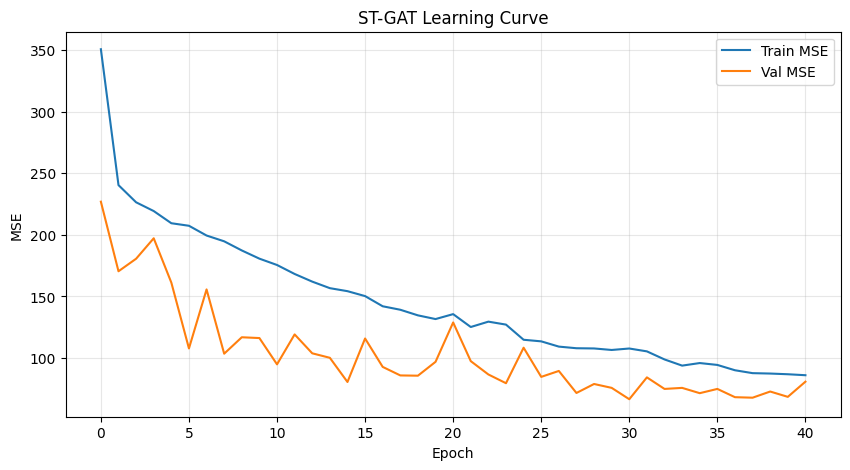

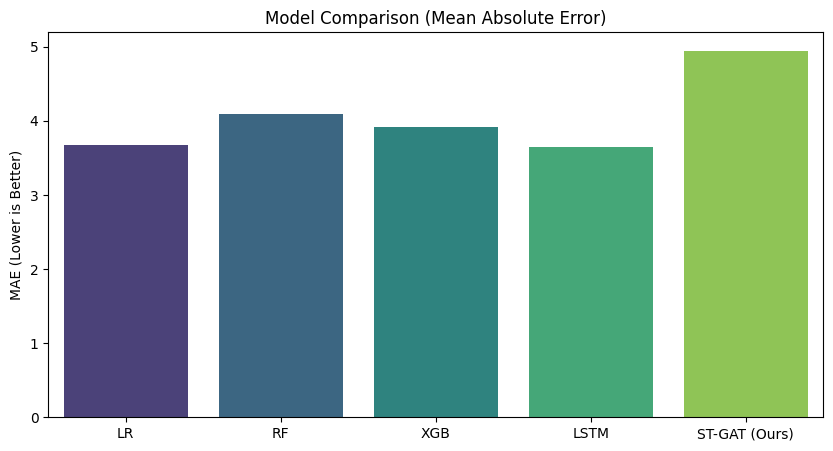


STARTING ABLATION STUDY
Building dynamic spatio-temporal graphs...

---> Training A_CrimeOnly
Epoch 001 | Train: 264.18 | Val: 105.34 | Top20_Acc: 70.1%
Epoch 002 | Train: 182.18 | Val: 104.53 | Top20_Acc: 72.8%
Epoch 003 | Train: 170.88 | Val: 88.88 | Top20_Acc: 72.8%
Epoch 004 | Train: 165.34 | Val: 80.60 | Top20_Acc: 74.3%
Epoch 005 | Train: 135.51 | Val: 72.53 | Top20_Acc: 73.6%
Epoch 006 | Train: 76.58 | Val: 67.27 | Top20_Acc: 75.8%
Epoch 007 | Train: 67.15 | Val: 72.92 | Top20_Acc: 77.4%
Epoch 008 | Train: 61.34 | Val: 56.78 | Top20_Acc: 78.1%
Epoch 009 | Train: 57.17 | Val: 53.92 | Top20_Acc: 78.7%
Epoch 010 | Train: 56.78 | Val: 52.67 | Top20_Acc: 78.8%
Epoch 011 | Train: 52.71 | Val: 55.69 | Top20_Acc: 79.2%
Epoch 012 | Train: 51.86 | Val: 63.20 | Top20_Acc: 79.3%
Epoch 013 | Train: 49.26 | Val: 62.81 | Top20_Acc: 79.8%
Epoch 014 | Train: 47.99 | Val: 60.28 | Top20_Acc: 79.8%
Epoch 015 | Train: 46.82 | Val: 58.52 | Top20_Acc: 79.6%
Epoch 016 | Train: 45.31 | Val: 53.45 | Top

In [ ]:
# CELL 8: Execute Everything
if not os.path.exists(Config.RAW_DATA_PATH):
    print(f"🛑 ERROR: Dataset not found at {Config.RAW_DATA_PATH}")
    print("Please upload 'crime_data.csv' to the /content/data/raw/ folder using the sidebar.")
else:
    # 1. Data Prep
    crime_df, surv_df = load_and_simulate_data(Config.RAW_DATA_PATH)
    crime_df, grid_mapping = create_spatial_grid(crime_df)
    panel, X_tensor, all_months, feature_cols = build_features(crime_df, surv_df, grid_mapping)

    # 2. Graphs
    edge_indices = build_dynamic_graphs(X_tensor, grid_mapping)
    train_loader, test_loader = create_dataloaders(X_tensor, edge_indices)

    # 3. Baselines
    ml_results = train_eval_ml_baselines(train_loader, test_loader)

    print("\n" + "="*40 + "\nTRAINING LSTM BASELINE (No Graph)\n" + "="*40)
    lstm_model = LSTMBase(num_features=X_tensor.shape[2])
    _, _, lstm_metrics = train_stgat(lstm_model, train_loader, test_loader)
    ml_results['LSTM'] = lstm_metrics

    # 4. Train ST-GAT
    print("\n" + "="*40 + "\nTRAINING ST-GAT MODEL\n" + "="*40)
    stgat_model = STGAT(num_features=X_tensor.shape[2], window_size=Config.WINDOW_SIZE)
    stgat_model, history, stgat_metrics = train_stgat(stgat_model, train_loader, test_loader)
    print_metrics(stgat_metrics, "Final ST-GAT Metrics")

    # 5. Visuals & Ablation
    plot_results(history, stgat_metrics, ml_results)
    run_ablation_study(X_tensor, grid_mapping)

    print("\n🎉 PIPELINE COMPLETE! All results and charts are saved in /content/reports/")